# The Lotka-Volterra model
This model is a python translation of the LV_pz model proposed in Glover et al. (2011), Sec. 9.3

You will need to make sure the required modules below are installed in your python environment

In [2]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

This is the function containing the right hand side of the ODE system

In [4]:
def LV_pz(x,t,p):
    X1,X2 = x
    p1,p2,p3,p4 = p
    dX1dt = X1 * (p1 - p2*X2)
    dX2dt = X2 * (p3*p2*X1 - p4)
    return np.array([dX1dt,dX2dt])

## parameters and initial conditions

In [5]:
# the parameters
p = np.array([0.1,0.4,0.2,0.05])
X1_0 = 0.8
X2_0 = 0.171
x0 = np.array([X1_0,X2_0])

## time axis

In [6]:
# time units are days
Tstart = 0.
Tend = 400.
step = 0.1
t = np.arange(Tstart,Tend,step)

## integration using the scipy ODE solver

In [7]:
# note that the extra argument containing the parameter "args" must be a tuple
y = odeint(LV_pz, x0, t, args=(p,))

## plot Fig. 9.3a

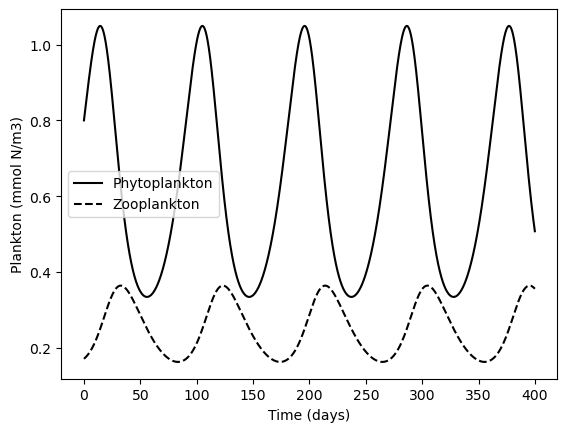

In [8]:
plt.plot(t,y[:,0],'k-',label='Phytoplankton')
plt.plot(t,y[:,1],'k--',label='Zooplankton')
plt.xlabel('Time (days)')
plt.ylabel('Plankton (mmol N/m3)')
plt.legend()
plt.show()

## Ocean Modelling: Exercise 3
#### AI Declaration: code from claud was used to write the code to create the plots
The L-V model cannot be solved analytically. Section 9.3.6 in the textbook above gives an example of a MATLAB computer code to resolve numerically the system of equations. This code is available in the python notebook LV pz.ipynb. It uses an ODE solver that we will understand more in detail fr: Numerical-time-integration. Run the code to reproduce the panel a from the previous figure. Modify the notebook to answer the following questions and upload it on your GitHub repository.

- Write the code to plot panel b in the appropriate cell block 
- Set the parameter p3 = 1 and compare how different the trajectory is in the phase space 
- Write the code to compute the solution of the L-V model using the initial conditions given in the caption of Fig. 9.4 in the Glover at al textbook and plot the results 
- Why are they different? Think about a few hypotheses and then see the explanation in the document Glover et al 2011 ERRATA.pdf

## Exercise 3
#### 1. Write the code to plot Fig. 9.3b - the trajectory in the phase space

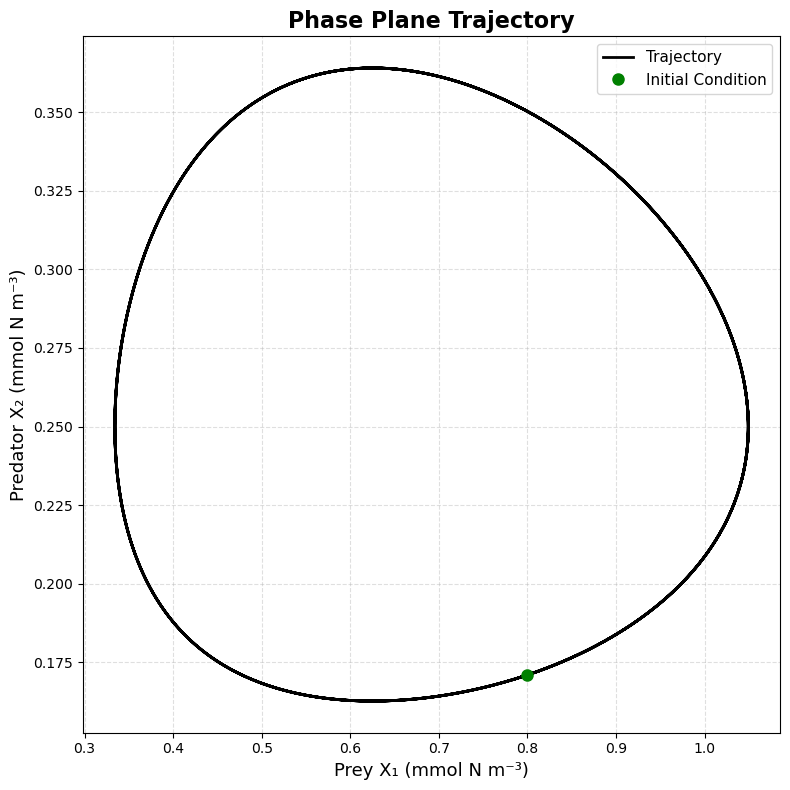

In [12]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(y[:,0], y[:,1], color='black', linewidth=2, label='Trajectory')
ax.plot(X1_0, X2_0, 'o', color='green', markersize=8, label='Initial Condition')

ax.set_title('Phase Plane Trajectory', fontsize=16, fontweight='bold')
ax.set_xlabel('Prey X₁ (mmol N m⁻³)', fontsize=13)
ax.set_ylabel('Predator X₂ (mmol N m⁻³)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

#### 2. Set the parameter p3=1 and compare how different the trajectory is in the phase space

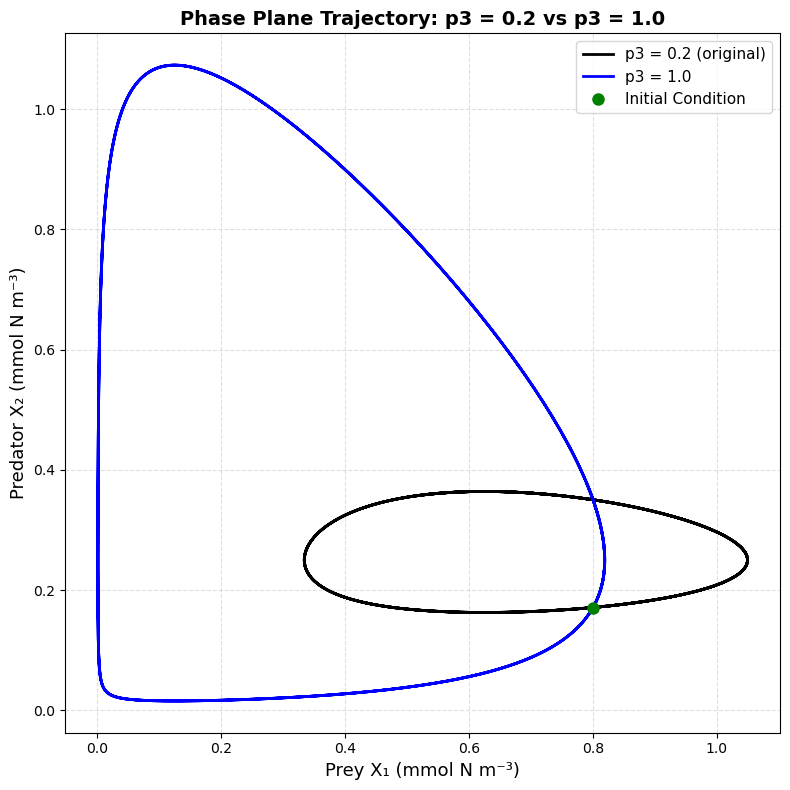

In [16]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(y_original[:, 0], y_original[:, 1], color='black',   linewidth=2, label='p3 = 0.2 (original)')
ax.plot(y_new[:, 0], y_new[:, 1], color='blue', linewidth=2, label='p3 = 1.0')
ax.plot(X1_0, X2_0, 'o', color='green', markersize=8, label='Initial Condition')

ax.set_title('Phase Plane Trajectory: p3 = 0.2 vs p3 = 1.0', fontsize=14, fontweight='bold')
ax.set_xlabel('Prey X₁ (mmol N m⁻³)', fontsize=13)
ax.set_ylabel('Predator X₂ (mmol N m⁻³)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

#### 3. Write the code to compute the solution of the L-V model using the initial conditions given in the caption of Fig. 9.4

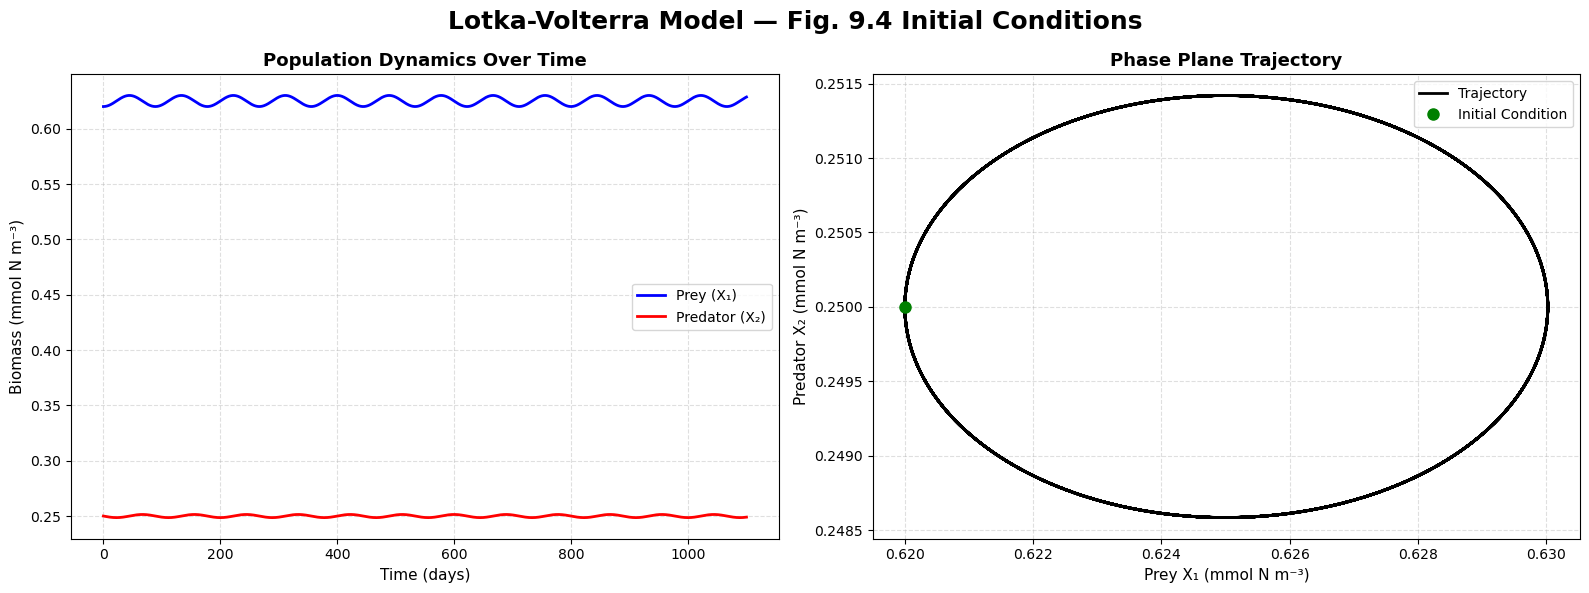

In [18]:
# new initial conditions (Fig. 9.4) 
X1_0_fig94 = 0.62
X2_0_fig94 = 0.25
x0_fig94   = np.array([X1_0_fig94, X2_0_fig94])
# time axis: 1100 days
t_fig94 = np.arange(0, 1100, 0.1)
# solve 
y_fig94 = odeint(LV_pz, x0_fig94, t_fig94, args=(p,))

# subplots: time series + phase plane 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Lotka-Volterra Model — Fig. 9.4 Initial Conditions', fontsize=18, fontweight='bold')

# 1. Time Series 
ax1.plot(t_fig94, y_fig94[:, 0], color='blue', linewidth=2, label='Prey (X₁)')
ax1.plot(t_fig94, y_fig94[:, 1], color='red', linewidth=2, label='Predator (X₂)')
ax1.set_title('Population Dynamics Over Time', fontsize=13, fontweight='bold')
ax1.set_xlabel('Time (days)', fontsize=11)
ax1.set_ylabel('Biomass (mmol N m⁻³)', fontsize=11)
ax1.legend(fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.4)

# 2. Phase Plane 
ax2.plot(y_fig94[:, 0], y_fig94[:, 1], color='black', linewidth=2, label='Trajectory')
ax2.plot(X1_0_fig94, X2_0_fig94, 'o', color='green', markersize=8, label='Initial Condition')
ax2.set_title('Phase Plane Trajectory', fontsize=13, fontweight='bold')
ax2.set_xlabel('Prey X₁ (mmol N m⁻³)', fontsize=11)
ax2.set_ylabel('Predator X₂ (mmol N m⁻³)', fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

#### 4. Do you get the same results? Why not? See the errata in the document Glover_etal_2011_ERRATA.pdf to understand more (no need to fully understand the stability analysis ;)

No, this is not the same as in Glover et al, 2011. This is because there is a typo in the parameters printed in the textbook and if these parameters are used then the same plot that appears in the textbook with the correct parameters cannot be reproduced with the incorrect parameters stated.